# <span style="color:Blue">Assignment-4 of COSC5806: Data Analysis with Python</span>

# <span style="color:Blue">Due date: Friday, March 13, 2026, @11:59 PM</span>
# <span style="color:Blue">Cut-off date: Sunday, March 15, 2026, @11:59 PM</span>

## <span style="color:Purple">You are allowed to use core Python's built in modules/packages/libraries, NumPy, Pandas, scikit-learn, matplotlib, and Seaborn. Please read the instruction carefully and do not hesitate to contact me if you have any questions.</span>

### <span style="color:Red">Examples and Resources for this assignment:</span>
<ul>
    <li><span style="color:Red">Chapters 3, 4, 5, 6, 7, 8, and 9 from <a href="https://docs.python.org/3/tutorial/index.html">The Python Tutorial</a></span></li>
    <li><span style="color:Red">Chapter 2 from <a href="https://jakevdp.github.io/PythonDataScienceHandbook/02.00-introduction-to-numpy.html">Introduction to NumPy</a></span></li>
    <li><span style="color:Red">Chapter 3 from <a href="https://jakevdp.github.io/PythonDataScienceHandbook/02.00-introduction-to-numpy.html">Data Manipulation with Pandas</a></span></li>
    <li><span style="color:Red">Chapter 2 from <a href="https://github.com/ageron/handson-ml3/blob/main/02_end_to_end_machine_learning_project.ipynb">End to End Machine Learning Project</a></span></li>
    <li><span style="color:Red">Chapter 4 from <a href="https://github.com/ageron/handson-ml3/blob/main/04_training_linear_models.ipynb">Training Linear Models</a></span></li>
</ul>

### <span style="color:Green">Context</span>
The attached CSV file contains daily weather data for the year 2024 for the city of Toronto, Ontario, Canada. It includes key meteorological variables such as:

<ul>
    <li><span><b>Date:</b> The recorded date of the weather data.</span></li>
    <li><span><b>Mean Temp ($^{\circ}$C):</b> The average daily temperature in degrees Celsius.</span></li>
    <li><span><b>Total Precip (mm):</b> The total daily precipitation (rain and melted snow) in millimeters.</span></li>
    <li><span><b>Snowfall (cm):</b> The amount of snowfall in centimeters.</span></li>
    <li><span><b>Wind Speed (km/h):</b> The recorded daily wind speed in kilometers per hour.</span></li>
</ul>

The following <a href="https://climate.weather.gc.ca/glossary_e.html">link</a> might be useful for the description of the features. With this dataset predict the mean temperature of a day.

In [16]:
# checking the versions of the libraries and the version of python being used in the environment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Seaborn version:", sns.__version__)
print("Scikit-learn version:", sklearn.__version__)

Pandas version: 2.2.3
NumPy version: 2.2.6
Seaborn version: 0.13.2
Scikit-learn version: 1.6.1


# <span style="color:Green">P1: Load the dataset.</span>

In [17]:
#loading the dataset we using the pandas library to read the csv file and store it in a dataframe called df
df=pd.DataFrame(pd.read_csv(r"C:\Users\MSI\Desktop\Toronto_Weather_Prediction\out.csv"))

# <span style="color:Green">P2: Print a quick description of the data.</span>

In [18]:
#we used the method head() to display the first 5 rows of the dataframe to get an overview of the data
#we used the method info() to get information about the dataframe, including the number of non-null values and the data types of each column
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Longitude (x)              1826 non-null   float64
 1   Latitude (y)               1826 non-null   float64
 2   Station Name               1826 non-null   object 
 3   Climate ID                 1826 non-null   int64  
 4   Date/Time                  1826 non-null   object 
 5   Year                       1826 non-null   int64  
 6   Month                      1826 non-null   int64  
 7   Day                        1826 non-null   int64  
 8   Data Quality               0 non-null      float64
 9   Max Temp (°C)              1818 non-null   float64
 10  Max Temp Flag              8 non-null      object 
 11  Min Temp (°C)              1818 non-null   float64
 12  Min Temp Flag              8 non-null      object 
 13  Mean Temp (°C)             1818 non-null   float

,Longitude (x),Latitude (y),Station Name,Climate ID,Date/Time,Year,Month,Day,Data Quality,Max Temp (°C),...,Total Snow (cm),Total Snow Flag,Total Precip (mm),Total Precip Flag,Snow on Grnd (cm),Snow on Grnd Flag,Dir of Max Gust (10s deg),Dir of Max Gust Flag,Spd of Max Gust (km/h),Spd of Max Gust Flag
0,-79.4,43.67,TORONTO CITY,6158355,2021-01-01,2021,1,1,NaN,2.5,...,NaN,NaN,6.8,NaN,NaN,NaN,NaN,M,NaN,M
1,-79.4,43.67,TORONTO CITY,6158355,2021-01-02,2021,1,2,NaN,2.2,...,NaN,NaN,10.8,NaN,0.0,NaN,NaN,M,NaN,M
2,-79.4,43.67,TORONTO CITY,6158355,2021-01-03,2021,1,3,NaN,2.1,...,NaN,NaN,1.7,NaN,0.0,NaN,NaN,M,NaN,M
3,-79.4,43.67,TORONTO CITY,6158355,2021-01-04,2021,1,4,NaN,1.7,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,M,NaN,M
4,-79.4,43.67,TORONTO CITY,6158355,2021-01-05,2021,1,5,NaN,1.6,...,NaN,NaN,0.4,NaN,NaN,NaN,NaN,M,NaN,M


# <span style="color:Green">P3: Display a summary of the numerical attributes.</span>

In [19]:
#we use the method describe() to get a statistical summary of the numerical columns in the dataframe, including count, mean, standard deviation, minimum, and maximum values
df.describe()

,Longitude (x),Latitude (y),Climate ID,Year,Month,Day,Data Quality,Max Temp (°C),Min Temp (°C),Mean Temp (°C),Heat Deg Days (°C),Cool Deg Days (°C),Total Rain (mm),Total Snow (cm),Total Precip (mm),Snow on Grnd (cm),Dir of Max Gust (10s deg),Spd of Max Gust (km/h)
count,1826.000000,1826.000000,1.826000e+03,1826.000000,1826.000000,1826.000000,0.0,1818.000000,1818.000000,1818.000000,1818.000000,1818.000000,364.000000,364.000000,1818.000000,411.000000,286.000000,286.000000
mean,-79.445975,43.671999,6.158430e+06,2023.000548,6.523549,15.727820,NaN,14.355116,6.413091,10.387624,8.826403,1.214026,1.690110,0.482418,2.208966,6.175182,24.667832,48.017483
std,0.092006,0.004000,1.504103e+02,1.414407,3.449478,8.801735,NaN,10.642347,9.555579,9.988180,8.549858,2.284929,5.516378,1.978735,6.026428,8.973047,8.422077,12.866237
min,-79.630000,43.670000,6.158355e+06,2021.000000,1.000000,1.000000,NaN,-12.600000,-20.500000,-16.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,31.000000
25%,-79.400000,43.670000,6.158355e+06,2022.000000,4.000000,8.000000,NaN,5.100000,-0.500000,2.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,22.000000,37.000000
50%,-79.400000,43.670000,6.158355e+06,2023.000000,7.000000,16.000000,NaN,14.550000,6.400000,10.300000,7.700000,0.000000,0.000000,0.000000,0.000000,3.000000,27.000000,45.000000
75%,-79.400000,43.670000,6.158355e+06,2024.000000,10.000000,23.000000,NaN,24.000000,15.000000,19.500000,15.700000,1.500000,0.200000,0.000000,1.300000,8.000000,31.000000,55.750000
max,-79.400000,43.680000,6.158731e+06,2025.000000,12.000000,31.000000,NaN,36.000000,24.800000,30.200000,34.500000,12.200000,48.100000,17.000000,83.600000,50.000000,36.000000,103.000000


# <span style="color:Green">P4: Plot a histogram for each numerical attribute.</span>

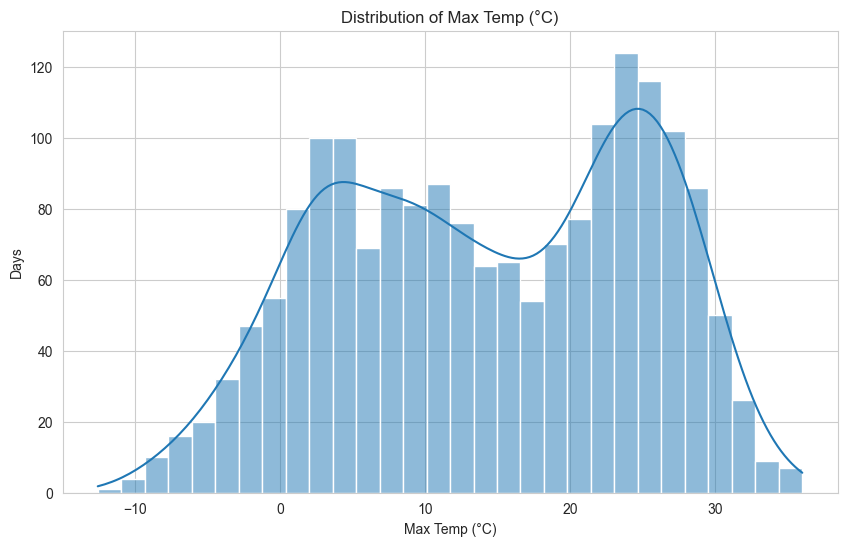

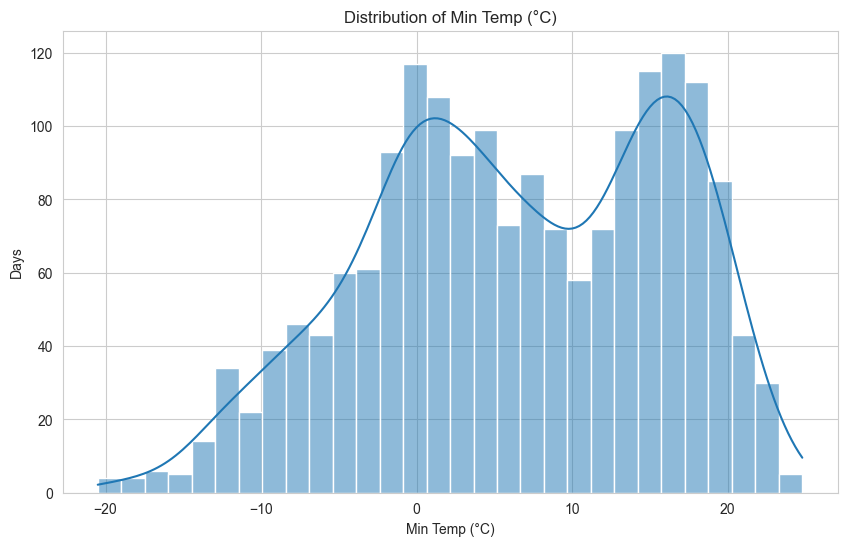

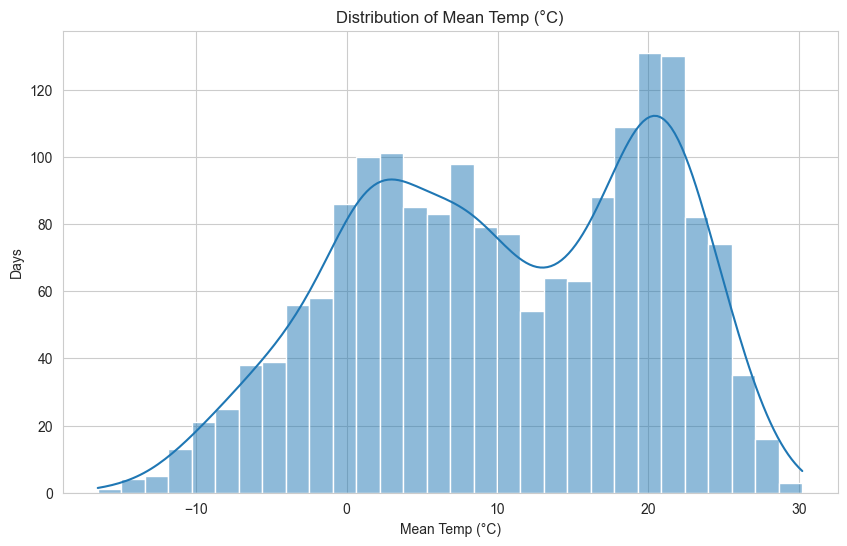

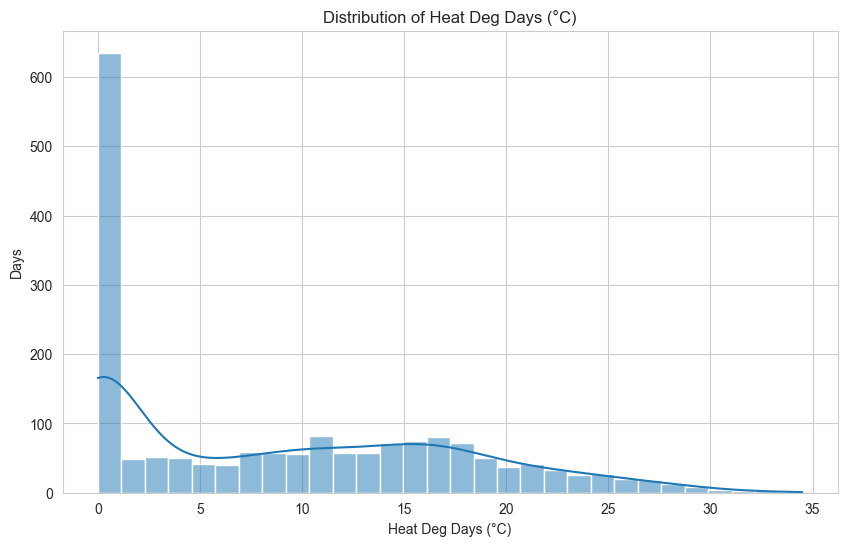

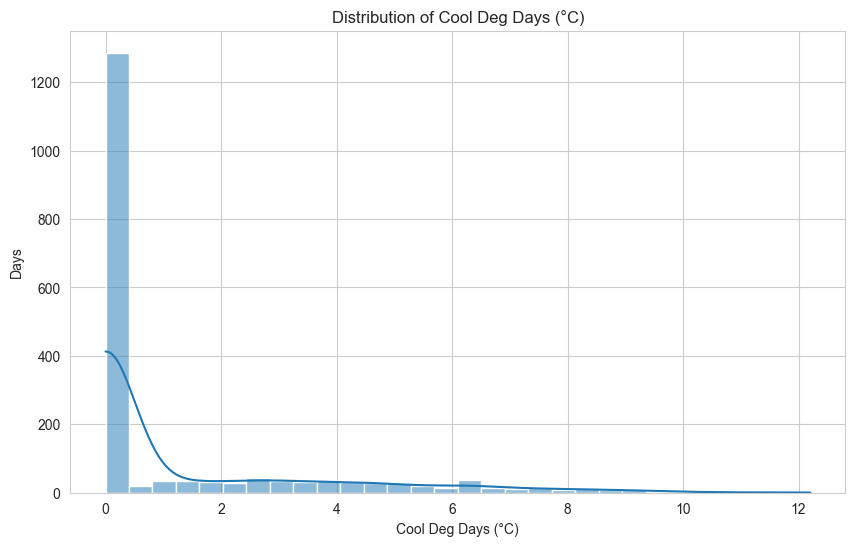

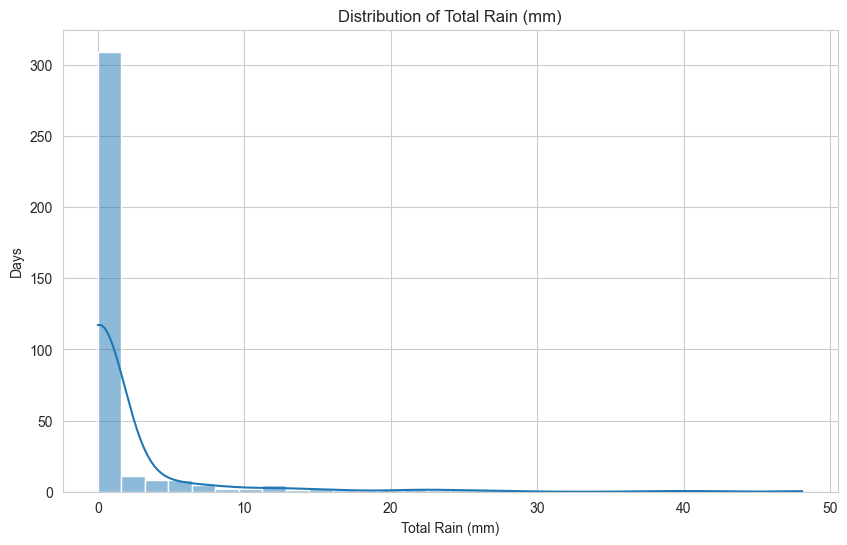

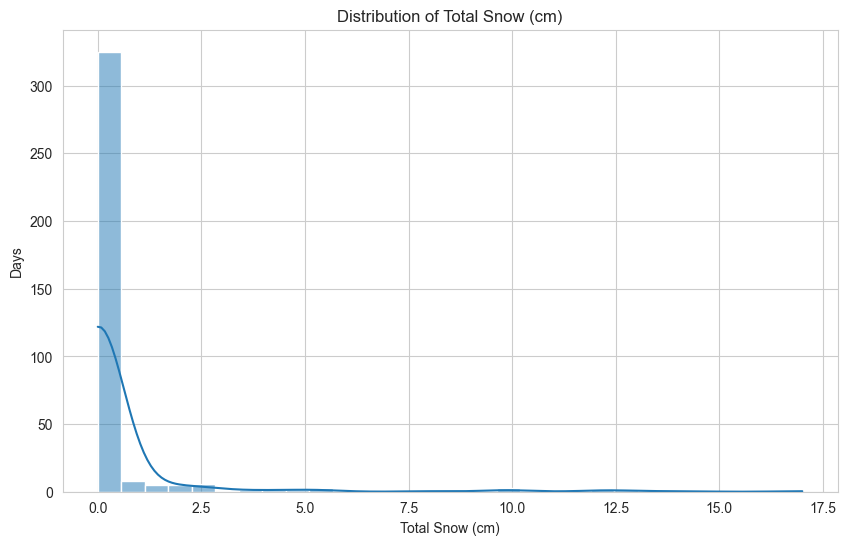

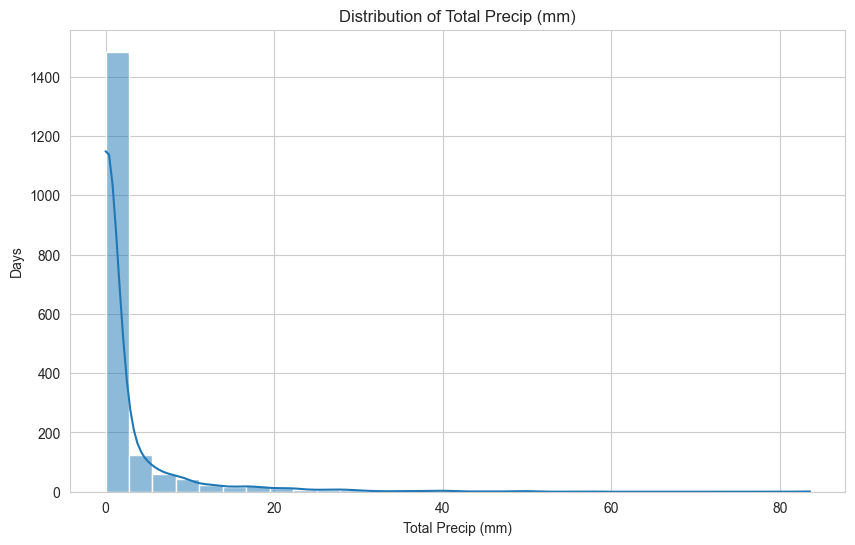

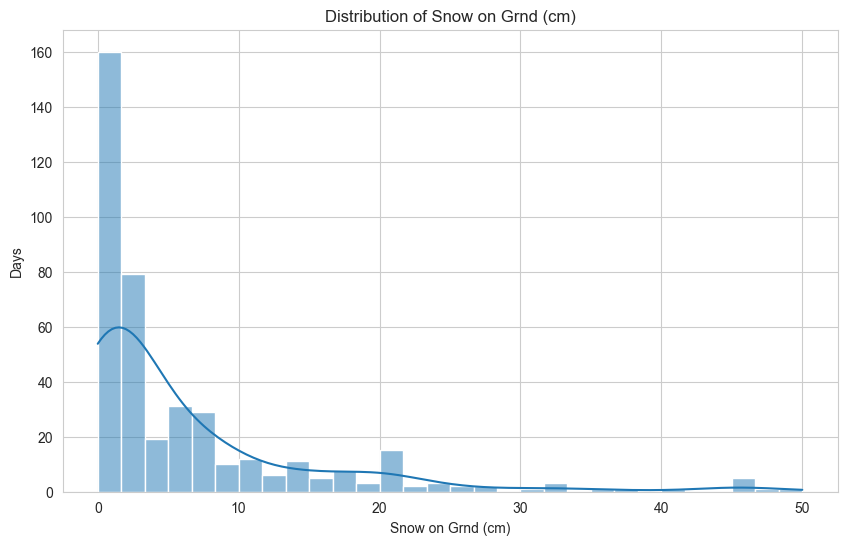

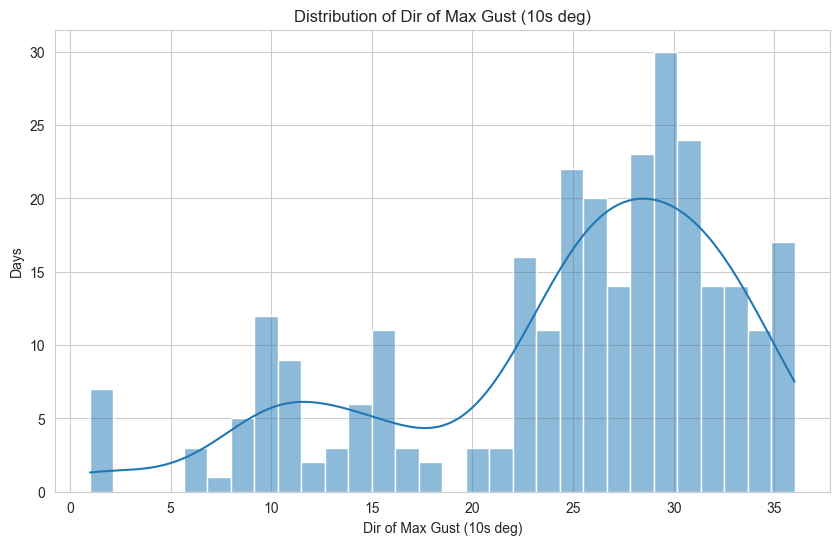

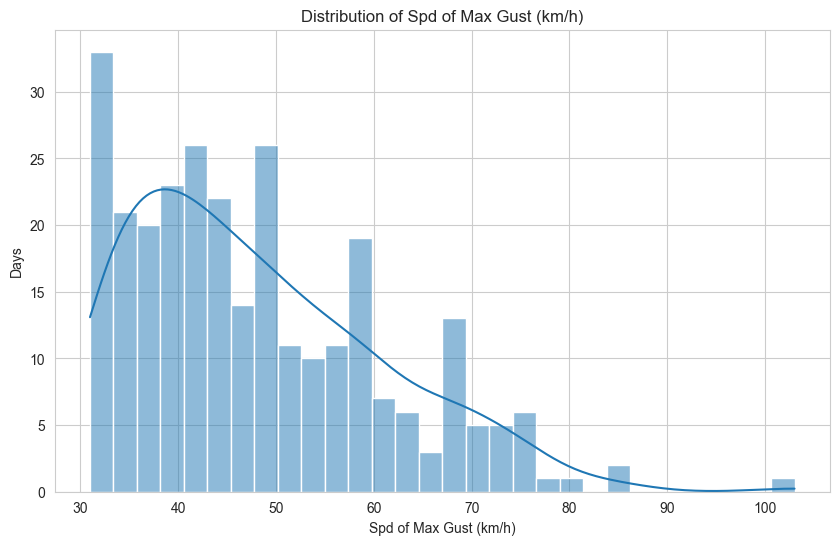

In [25]:
#we are taking the numerical columns and using seaborn to create histograms for each numerical column to visualize the distribution of the data.
# We set the style to "whitegrid" for better aesthetics and specify the figure size.
# We also add a kernel density estimate (kde) to the histogram for a smoother representation of the distribution.
# Finally, we set the title and labels for each plot and display them.
num_cols=df.select_dtypes(include=["float64","int64"]).columns
nums_cols = num_cols.drop(["Longitude (x)", "Latitude (y)", "Climate ID", "Date/Time","Year","Month","Day","Data Quality",""], errors='ignore')
for col in nums_cols:
  sns.set_style("whitegrid")
  plt.figure(figsize=(10,6))
  sns.histplot(df[col], kde=True, bins=30)
  plt.title(f"Distribution of {col}")
  plt.xlabel(col)
  plt.ylabel("Days")
  plt.show()
    



# <span style="color:Green">P5: Compute the standard correlation coefficient (also called Pearson’s r) between every pair of attributes.</span>

In [ ]:
#Codes of P5 here

# <span style="color:Green">P6: Set the missing values to the median (if any).</span>

In [ ]:
#Codes of P6 here

# <span style="color:Green">P7: Split your dataset into training set (80%) and test set (20%).</span>

In [ ]:
#Codes of P7 here

# <span style="color:Green">P8: Use LinearRegression, DecisionTreeRegressor, and RandomForestRegressor to train your model. (apply 5-fold cross validation). For each regression model calculate and print RMSE score. </span>

In [ ]:
#Codes of P8 here

# <span style="color:Green">P9: Calculate and print RMSE score for the test set. </span>

In [ ]:
#Codes of P9 here

# <span style="color:Green">P10: Predict the mean temperature of a date and compare it with the actual mean temperature.</span>

In [ ]:
#Codes of P10 here

### <span style="color:Red">Please submit only your complete Jupyter notebook (.ipynb) file. Do not submit compressed files, entire projects, or any other types of files. Comment your program carefully so that it can be read and understood. If your program is not properly commented, you may lose marks. See \textbf{marking scheme} for details.</span>

### <span style="color:Red">Please note that the submitted work will be considered as your own work and you confirm that you have not received any unauthorized assistance including Large Language Models (LLMs) in preparing for or doing this lab/assignment/examination. You confirm knowing that a mark of 0 may be assigned for entire work.</span>

### <span style="color:Red">You will receive full credits for the working code, otherwise zero. No partial credits!</span>